## Imports

In [1]:
import pickle
import random
from typing import List, Tuple
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from maze import *

## Setup

In [3]:
def load_samples(pkl_path: str, n_samples: int = 2000, seed: int = 0):
    with open(pkl_path, 'rb') as f:
        all_data = pickle.load(f)
    random.Random(seed).shuffle(all_data)
    picked = all_data[:n_samples]
    mazes = []
    lengths = []

    for maze, length in picked:
        arr = np.array(maze, dtype=np.float32)

        H, W = arr.shape
        newH = H + 1
        newW = W + 1
        padded = np.zeros((newH, newW), dtype=np.float32)
        padded[:H, :W] = arr

        mazes.append(padded)
        lengths.append(float(length))

    return mazes, lengths


In [4]:
class MazeDataset(Dataset):
    def __init__(self, mazes: List[np.ndarray], lengths: List[float]):
        assert len(mazes) == len(lengths)
        self.mazes = mazes
        self.lengths = lengths
        self.n = len(mazes)
        # assume all mazes same shape
        self.h, self.w = mazes[0].shape


    def __len__(self):
        return self.n


    def __getitem__(self, idx):
        maze = self.mazes[idx]
        length = self.lengths[idx]
        # normalize length to float32 and scale roughly to [0,1]
        return torch.from_numpy(maze).unsqueeze(0), torch.tensor(length, dtype=torch.float32)

## Conditional Variational Autoencoder

In [5]:
F = torch.nn.functional

class ConvEncoder(nn.Module):
    def __init__(self, latent_dim=64, in_size=(20,20)):
        super().__init__()
        # assume input H,W divisible by 4 (20x20 common). adjust if needed.
        self.conv1 = nn.Conv2d(1, 32, 4, 2, 1)   # H/2
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)  # H/4
        self.conv3 = nn.Conv2d(64, 128, 3, 1, 1)
        H, W = in_size
        feat_h = H // 4
        feat_w = W // 4
        
        self._flat = 128 * feat_h * feat_w
        self.fc_mu = nn.Linear(self._flat, latent_dim)
        self.fc_logvar = nn.Linear(self._flat, latent_dim)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.act(self.conv3(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class ConvDecoder(nn.Module):
    def __init__(self, latent_dim=64, len_emb_dim=16, out_size=(20,20)):
        super().__init__()
        H, W = out_size
        feat_h = H // 4
        feat_w = W // 4
        self.fc = nn.Linear(latent_dim + len_emb_dim, 128 * feat_h * feat_w)
        self.act = nn.GELU()
        self.deconv1 = nn.ConvTranspose2d(128, 64, 4, 2, 1)  # *2
        self.deconv2 = nn.ConvTranspose2d(64, 32, 4, 2, 1)   # *2
        self.outc = nn.Conv2d(32, 1, 3, 1, 1)
    def forward(self, zc, H, W):
        h = self.fc(zc)
        feat_h = H // 4
        feat_w = W // 4
        h = h.view(h.size(0), 128, feat_h, feat_w)
        h = self.act(h)
        h = self.act(self.deconv1(h))
        h = self.act(self.deconv2(h))
        logits = self.outc(h)
        return logits


In [6]:
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=64, len_emb_dim=16, in_size=(20,20)):
        super().__init__()
        self.enc = ConvEncoder(latent_dim=latent_dim, in_size=in_size)
        self.len_embed = nn.Sequential(nn.Linear(1, len_emb_dim), nn.GELU(), nn.Linear(len_emb_dim, len_emb_dim))
        self.dec = ConvDecoder(latent_dim=latent_dim, len_emb_dim=len_emb_dim, out_size=in_size)
        self.latent_dim = latent_dim
        self.in_size = in_size

    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, length):
        mu, logvar = self.enc(x)
        z = self.reparam(mu, logvar)
        le = self.len_embed(length.unsqueeze(1))
        zc = torch.cat([z, le], dim=1)
        logits = self.dec(zc, *self.in_size)
        return logits, mu, logvar

    def generate(self, length, n=1, device='cpu'):
        self.to(device)
        self.eval()
        with torch.no_grad():
            z = torch.randn(n, self.latent_dim, device=device)
            le = torch.tensor([length]*n, dtype=torch.float32, device=device).unsqueeze(1)
            le = self.len_embed(le)
            zc = torch.cat([z, le], dim=1)
            logits = self.dec(zc, *self.in_size)
            probs = torch.sigmoid(logits)
            return (probs > 0.5).long().cpu().numpy().squeeze(1)


In [7]:
def kld_loss(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

def train_cvae(pkl_path='mazes.pkl', n_samples=2000, batch_size=64, epochs=20, lr=1e-3, latent_dim=64, device='mps'):
    mazes, lengths = load_samples(pkl_path, n_samples=n_samples)
    # infer input size from first sample
    H, W = mazes[0].shape
    ds = MazeDataset(mazes, lengths)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    model = ConditionalVAE(latent_dim=latent_dim, len_emb_dim=16, in_size=(H,W)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()
    beta = 1e-3

    recon_hist = []
    kld_hist = []
    for epoch in range(1, epochs+1):
        model.train()
        running_r = 0.0
        running_k = 0.0
        for xb, lengths in dl:
            xb = xb.to(device)
            lengths = lengths.to(device)
            opt.zero_grad()
            logits, mu, logvar = model(xb, lengths)
            loss_recon = bce(logits, xb)
            loss_kld = kld_loss(mu, logvar)
            loss = loss_recon + beta * loss_kld
            loss.backward()
            opt.step()
            running_r += loss_recon.item()
            running_k += loss_kld.item()
        avg_r = running_r / len(dl)
        avg_k = running_k / len(dl)
        recon_hist.append(avg_r); kld_hist.append(avg_k)
        print(f"Epoch {epoch}: recon={avg_r:.4f} kld={avg_k:.6f} total={(avg_r+beta*avg_k):.4f}")
    # final loss plot
    plt.figure(); plt.plot(recon_hist,label='recon'); plt.plot(kld_hist,label='kld'); plt.legend(); plt.show()
    return model


Epoch 1: recon=0.3836 kld=1.736787 total=0.3853
Epoch 2: recon=0.3123 kld=1.277312 total=0.3136
Epoch 3: recon=0.3084 kld=1.055496 total=0.3095
Epoch 4: recon=0.3077 kld=0.838570 total=0.3086
Epoch 5: recon=0.3073 kld=0.733946 total=0.3081
Epoch 6: recon=0.3070 kld=0.619442 total=0.3076
Epoch 7: recon=0.3070 kld=0.576356 total=0.3076
Epoch 8: recon=0.3065 kld=0.536880 total=0.3070
Epoch 9: recon=0.3025 kld=1.047869 total=0.3035
Epoch 10: recon=0.2835 kld=1.900581 total=0.2854
Epoch 11: recon=0.2663 kld=2.233453 total=0.2685
Epoch 12: recon=0.2516 kld=2.820368 total=0.2544
Epoch 13: recon=0.2251 kld=3.303033 total=0.2284
Epoch 14: recon=0.1974 kld=3.942009 total=0.2014
Epoch 15: recon=0.1670 kld=4.597250 total=0.1716
Epoch 16: recon=0.1350 kld=5.194324 total=0.1402
Epoch 17: recon=0.1089 kld=5.483257 total=0.1144
Epoch 18: recon=0.0910 kld=5.574952 total=0.0966
Epoch 19: recon=0.0797 kld=5.650552 total=0.0853
Epoch 20: recon=0.0696 kld=5.998319 total=0.0756
Epoch 21: recon=0.0608 kld=6.

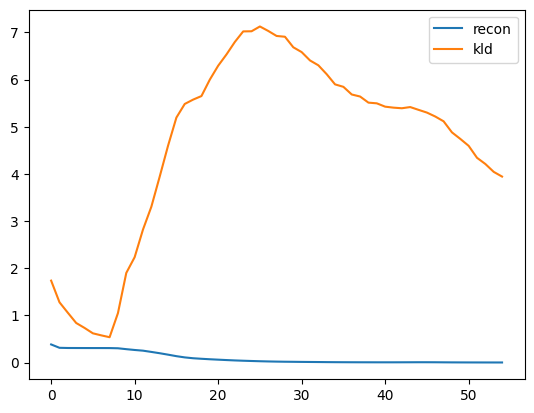

In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
model = train_cvae(pkl_path='mazesC.pkl', n_samples=2000, batch_size=64, epochs=55, lr=1e-3, latent_dim=64, device=device)


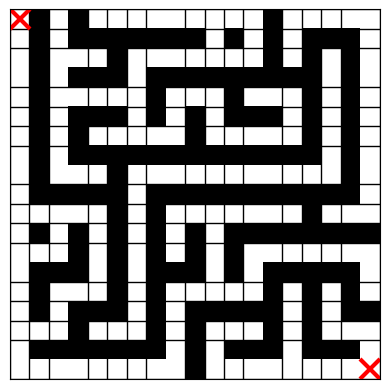

-1


In [9]:
sample = model.generate(67.0, n=1, device=device)
sample = sample[0][:, :19]      # remove last row
sample = sample[:19, :]      # remove last column
visualize_maze(sample, text=False)
print(maze_path_length(sample))

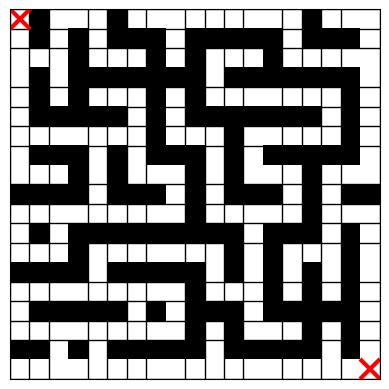

-1


In [10]:
sample = model.generate(100.0, n=1, device=device)
sample = sample[0][:, :19]      # remove last row
sample = sample[:19, :]      # remove last column
visualize_maze(sample, text=False)
print(maze_path_length(sample))

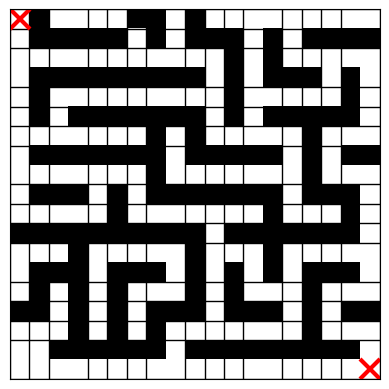

40


In [11]:
sample = model.generate(40, n=1, device=device)
sample = sample[0][:, :19]      # remove last row
sample = sample[:19, :]      # remove last column
visualize_maze(sample, text=False)
print(maze_path_length(sample))

In [14]:
# RL latent policy: train only z-sampling policy, keep CVAE frozen


class LatentPolicy(nn.Module):
    def __init__(self, latent_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.log_std = nn.Parameter(torch.zeros(latent_dim))

    def forward(self, lengths: torch.Tensor):
        h = self.backbone(lengths.unsqueeze(1))
        mu = self.mu_head(h)
        log_std = self.log_std.clamp(-5.0, 2.0).unsqueeze(0).expand_as(mu)
        return mu, log_std

    def sample(self, lengths: torch.Tensor):
        mu, log_std = self(lengths)
        std = log_std.exp()
        dist = torch.distributions.Normal(mu, std)
        z = dist.sample()
        logp = dist.log_prob(z).sum(dim=1)
        ent = dist.entropy().sum(dim=1)
        return z, logp, ent


@torch.no_grad()
def sample_lengths_from_data(lengths, n: int, device: str):
    idx = torch.randint(0, len(lengths), (n,), device=device)
    return torch.tensor([float(lengths[i]) for i in idx.tolist()], dtype=torch.float32, device=device)


def train_latent_policy_reinforce(
    model,
    f_solvable,
    lengths_data,
    steps: int = 3000,
    batch_size: int = 64,
    lr: float = 1e-4,
    device: str = "mps",
    entropy_bonus: float = 1e-3,
    temperature: float = 1.0,
):
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)

    policy = LatentPolicy(latent_dim=model.latent_dim).to(device)
    opt = torch.optim.Adam(policy.parameters(), lr=lr)

    baseline = 0.0
    baseline_momentum = 0.95
    H, W = model.in_size

    for step in range(1, steps + 1):
        lengths = sample_lengths_from_data(lengths_data, batch_size, device)
        z, logp_z, ent_z = policy.sample(lengths)

        with torch.no_grad():
            le = model.len_embed(lengths.unsqueeze(1))
            zc = torch.cat([z, le], dim=1)
            logits = model.dec(zc, H, W) / temperature
            probs = torch.sigmoid(logits).clamp(1e-6, 1 - 1e-6)
            x = torch.bernoulli(probs)

        x_np = x.detach().cpu().numpy().astype("int32")[:, 0]
        r = torch.tensor([1.0 if f_solvable(m) else 0.0 for m in x_np], dtype=torch.float32, device=device)

        r_mean = r.mean().item()
        baseline = baseline_momentum * baseline + (1.0 - baseline_momentum) * r_mean
        adv = (r - baseline).detach()

        loss_pg = -(adv * logp_z).mean()
        loss_ent = -entropy_bonus * ent_z.mean()
        loss = loss_pg + loss_ent

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        opt.step()

        if step % 50 == 0:
            print(f"step {step:5d}  solv_rate={r_mean:.3f}  baseline={baseline:.3f}  loss={loss.item():.3f}")

    return policy


@torch.no_grad()
def generate_with_policy(model, policy, length: float, n: int = 1, device: str = "cpu", deterministic: bool = True):
    model = model.to(device).eval()
    policy = policy.to(device).eval()

    lengths = torch.full((n,), float(length), dtype=torch.float32, device=device)
    mu, log_std = policy(lengths)
    if deterministic:
        z = mu
    else:
        z = mu + torch.randn_like(mu) * log_std.exp()

    le = model.len_embed(lengths.unsqueeze(1))
    zc = torch.cat([z, le], dim=1)
    logits = model.dec(zc, *model.in_size)
    probs = torch.sigmoid(logits)
    return (probs > 0.5).long().cpu().numpy().squeeze(1)


# Example usage:
# policy = train_latent_policy_reinforce(loaded_model, f_solvable=f, lengths_data=lengths, steps=3000, batch_size=64, lr=1e-4, device=device)
# sample = generate_with_policy(loaded_model, policy, length=100.0, n=1, device=device, deterministic=True)


In [15]:
def maze_path_length(maze: list[list[int]], start: tuple = (0, 0), end: tuple | None = None) -> int:
    if end is None:
        end = (len(maze) - 1, len(maze[0]) - 1)
    startx, starty = start
    endx, endy = end
    if maze[startx][starty] == 1 or maze[endx][endy] == 1:
        return -1
    r, c = len(maze), len(maze[0])
    visited = [[False for _ in range(c)] for _ in range(r)]
    visited[startx][starty] = True
    queue = deque()
    queue.append((startx, starty, 0))
    directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
    while queue:
        x, y, dist = queue.popleft()
        if (x, y) == (endx, endy):
            return dist
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < r and 0 <= ny < c and not visited[nx][ny] and maze[nx][ny] == 0:
                visited[nx][ny] = True
                queue.append((nx, ny, dist + 1))
    return -1

def f(maze: list[list[int]], start: tuple = (0, 0), end: tuple | None = None) -> int:
    return 1 if maze_path_length(maze, start, end) != -1 else 0


In [16]:
n_samples = 2000
mazes, lengths = load_samples(pkl_path = "mazesC.pkl", n_samples=n_samples)

policy = train_latent_policy_reinforce(
      loaded_model='base_model.pt',
      f_solvable=f,
      lengths_data=lengths,   # your dataset length list
      steps=3000,
      batch_size=64,
      lr=1e-4,
      device=device,
  )


step    50  solv_rate=0.625  baseline=0.588  loss=3.608
step   100  solv_rate=0.641  baseline=0.666  loss=-2.862
step   150  solv_rate=0.703  baseline=0.705  loss=-0.393
step   200  solv_rate=0.734  baseline=0.715  loss=1.316
step   250  solv_rate=0.688  baseline=0.752  loss=-5.615
step   300  solv_rate=0.859  baseline=0.793  loss=6.070
step   350  solv_rate=0.844  baseline=0.816  loss=2.657
step   400  solv_rate=0.844  baseline=0.857  loss=-1.586
step   450  solv_rate=0.891  baseline=0.896  loss=-0.250
step   500  solv_rate=0.969  baseline=0.913  loss=5.185
step   550  solv_rate=1.000  baseline=0.934  loss=5.897
step   600  solv_rate=0.922  baseline=0.935  loss=-1.210
step   650  solv_rate=0.969  baseline=0.942  loss=2.352
step   700  solv_rate=0.969  baseline=0.937  loss=2.854
step   750  solv_rate=0.953  baseline=0.956  loss=-0.275
step   800  solv_rate=0.891  baseline=0.942  loss=-5.127
step   850  solv_rate=0.938  baseline=0.949  loss=-1.461
step   900  solv_rate=0.984  baseline=0

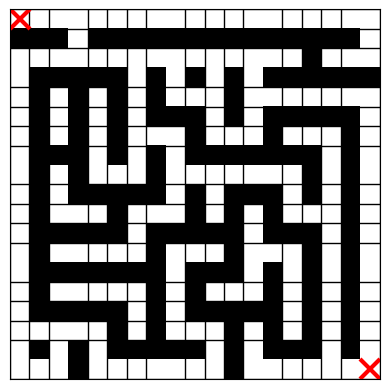

36


In [17]:
  sample = generate_with_policy(
      loaded_model,
      policy,
      length=67,
      n=1,
      device="mps",
      deterministic=True,   # set False for random variation
  )

  sample = sample[0][:19, :19]    # crop to 19x19
  visualize_maze(sample, text=False)
  print(maze_path_length(sample))

Number of -1 values: 50
80.0% solvable


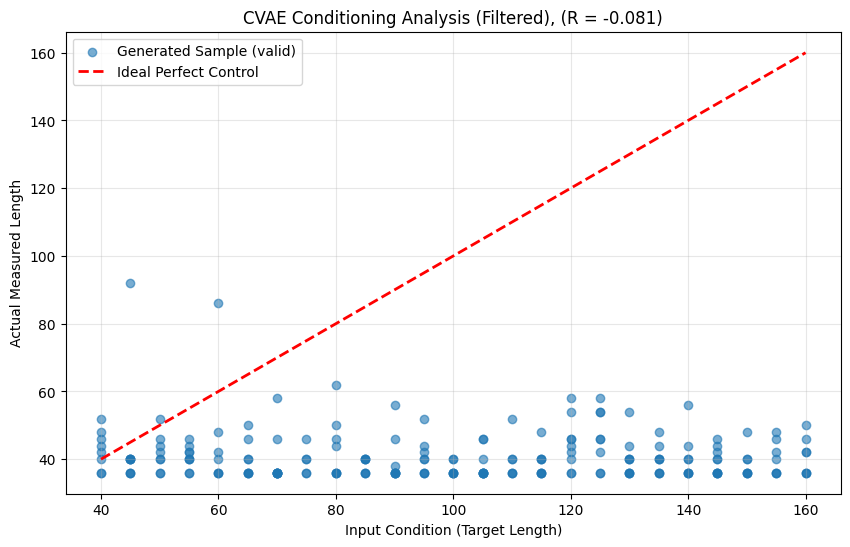

In [18]:
loaded_model.eval()
policy.eval()

input_vals = []
measured_vals = []

for tgt in range(40, 161, 5):
    mazes = generate_with_policy(
        loaded_model,
        policy,
        length=float(tgt),
        n=10,
        device="mps",
        deterministic=False,
    )
    for i in range(10):
        m = mazes[i][:19, :19]
        actual = maze_path_length(m)
        input_vals.append(tgt)
        measured_vals.append(actual)

input_vals = np.array(input_vals)
measured_vals = np.array(measured_vals)

# count -1 values
num_neg1 = np.sum(measured_vals == -1)
print(f"Number of -1 values: {num_neg1}")
print(f"{(len(measured_vals)-num_neg1)/(len(measured_vals))*100}% solvable")

# mask valid values
valid_mask = measured_vals != -1
x_valid = input_vals[valid_mask]
y_valid = measured_vals[valid_mask]

# ---- plot (filtered) ----
plt.figure(figsize=(10, 6))
plt.scatter(x_valid, y_valid, alpha=0.6, label='Generated Sample (valid)')
plt.plot([40, 160], [40, 160], 'r--', lw=2, label='Ideal Perfect Control')

r_value = np.corrcoef(x_valid, y_valid)[0, 1]

plt.xlabel("Input Condition (Target Length)")
plt.ylabel("Actual Measured Length")
plt.title(f"CVAE Conditioning Analysis (Filtered), (R = {r_value:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
